In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
from statsmodels.stats.multitest import multipletests

In [3]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

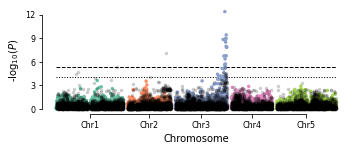

In [10]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)

classic=parse('FO_leaf_B_blues.assoc.txt.gz')
covariate=parse('FO_leaf_B_blues_BOR1_TD_cov.assoc.txt.gz')

rejected, pvals_corrected, _, _ = multipletests(classic['p_lrt'], alpha=0.1, method='fdr_bh')
classic["Significant"] = rejected
classic["FDR_corrected_pval"] = pvals_corrected

cm = 1/2.54
fig = plt.figure(figsize=(14*cm,5*cm))
ax =sns.scatterplot(x='position',
                y='P',
                data=covariate,
                hue='chr',
                palette='Set2',
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
sns.scatterplot(x='position',
                y='P',
                data=classic,
#                 hue='chr',
                marker='o',
                color='black',
#                 facecolors='none',
#                 edgecolors='r',
#                 edgecolors='0',
                alpha=.2,
                linewidth=0,
                s=12,
#                 linewidth=80,
                legend=False,
                zorder=3)

plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
plt.hlines(y=classic[classic["Significant"] == True]['P'].min(),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle=':',
             linewidth=1,
#              alpha=0.4,
             zorder=1)

# plt.ylim(0,13)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(3))
plt.xlabel('Chromosome',fontsize=10)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.savefig("Fig5c.png", format="png",bbox_inches="tight",facecolor="w",dpi=300)

In [11]:
covariate.sort_values(by='P',ascending=False).head(10)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
7551,3,3:22436584,22436584,2,A,T,0.395,13.42462,1.292782,1.584884,1.497400,1.598794e-18,4.327876e-13,1.115262e-07,12.363725,-12.363725,76562544
7600,3,3:23067258,23067258,9,C,T,0.410,12.03595,1.330258,1.703548,1.627851,2.656687e-15,3.884488e-10,4.687368e-06,9.410666,-9.410666,77193218
7576,3,3:22776067,22776067,9,A,G,0.402,11.54754,1.370241,2.107557,2.036680,7.852778e-14,1.087047e-09,5.596148e-06,8.963752,-8.963752,76902027
7598,3,3:23044100,23044100,7,C,T,0.395,11.82191,1.369768,1.905366,1.834904,2.604989e-14,1.097873e-09,7.477010e-06,8.959448,-8.959448,77170060
7453,3,3:21656886,21656886,3,G,A,0.301,11.21170,1.560312,4.181861,4.107911,5.640561e-11,1.480686e-09,7.901312e-07,8.829537,-8.829537,75782846
7567,3,3:22632105,22632105,8,A,G,0.381,10.82640,1.396868,2.823849,2.750595,2.947473e-12,2.126531e-09,2.777985e-06,8.672328,-8.672328,76758065
7583,3,3:22827669,22827669,11,C,A,0.400,10.63340,1.355199,2.571407,2.505185,1.773028e-12,3.224214e-09,4.277077e-06,8.491576,-8.491576,76953629
7594,3,3:23003946,23003946,7,A,T,0.353,11.07073,1.692914,5.105996,5.056752,1.483440e-09,1.103634e-08,1.887800e-06,7.957175,-7.957175,77129906
7623,3,3:23307100,23307100,9,A,C,0.419,10.86620,1.496049,3.063329,2.967203,3.775754e-11,1.363623e-08,4.787284e-06,7.865306,-7.865306,77433060
7613,3,3:23233267,23233267,6,C,T,0.417,12.01329,1.547664,2.320309,2.188973,2.770147e-12,1.513543e-08,1.084892e-05,7.820005,-7.820005,77359227
